In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import joblib
import numpy as np


# Supermarket Sales Analysis & Gross Income Prediction

## 📊 Project Overview
This project analyzes supermarket sales data to predict gross income using machine learning techniques. The dataset contains 1000 transactions with features including branch location, customer type, product line, payment method, and sales metrics. The project implements a Random Forest Regressor model with comprehensive hyperparameter tuning using both GridSearchCV and RandomizedSearchCV.

## 🎯 Objectives
- Perform exploratory data analysis (EDA) on sales data
- Build a predictive model for gross income using machine learning
- Optimize model performance through hyperparameter tuning (GridSearchCV and RandomizedSearchCV)
- Evaluate model performance using multiple metrics (RMSE, MAE, R² Score)
- Compare baseline and tuned models
- Save and prepare models for deployment


In [46]:
df = pd.read_csv('SuperMarket Analysis.csv')
df.sample(5)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
87,633-44-8566,Alex,Yangon,Member,Female,Food and beverages,49.38,7,17.283,362.943,3/27/2019,8:35:00 PM,Credit card,345.66,4.761905,17.283,7.3
330,868-81-1752,Cairo,Mandalay,Normal,Male,Home and lifestyle,22.02,9,9.909,208.089,2/7/2019,6:48:00 PM,Cash,198.18,4.761905,9.909,6.8
220,239-36-3640,Cairo,Mandalay,Normal,Male,Electronic accessories,45.35,6,13.605,285.705,1/31/2019,1:44:00 PM,Ewallet,272.10,4.761905,13.605,6.1
797,864-24-7918,Alex,Yangon,Member,Female,Sports and travel,24.49,10,12.245,257.145,2/22/2019,3:15:00 PM,Cash,244.90,4.761905,12.245,8.1
269,731-14-2199,Alex,Yangon,Member,Female,Home and lifestyle,35.54,10,17.770,373.170,1/4/2019,1:34:00 PM,Ewallet,355.40,4.761905,17.770,7.0


In [47]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [49]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


# 
# ## Experiments Performed
# 1. **Data Overview**: Dataset shape, data types, and basic statistics
# 2. **Missing Values Check**: Verified no missing values in the dataset
# 3. **Sales Distribution Analysis**: 
#    - Sales by Branch (boxplot)
#    - Sales by Product Line (boxplot)
# 4. **Customer Rating Analysis**:
#    - Rating distribution (histogram)
#    - Rating by Customer Type (boxplot)
# 5. **Statistical Testing**: 
#    - T-test comparing sales between Member and Normal customers
#    - Result: p-value = 0.0611 (borderline significant)
# 

In [50]:
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

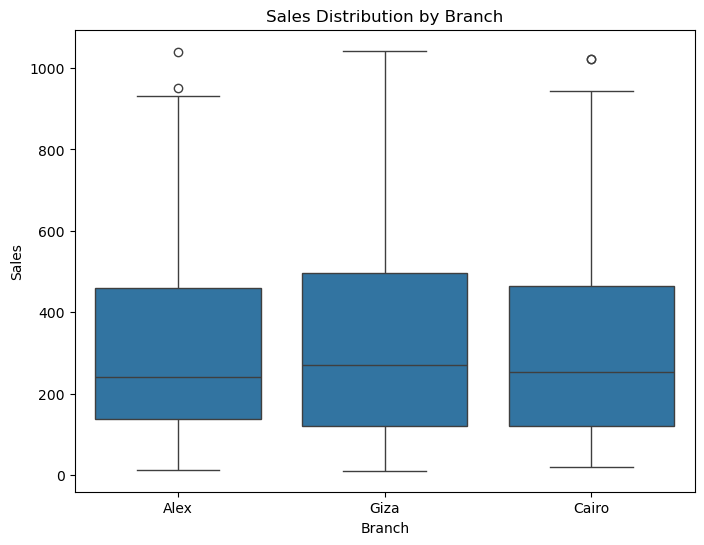

In [51]:
# Plot sales by branch
plt.figure(figsize=(8, 6))
sns.boxplot(x='Branch', y='Sales', data=df)
plt.title('Sales Distribution by Branch')
plt.show()

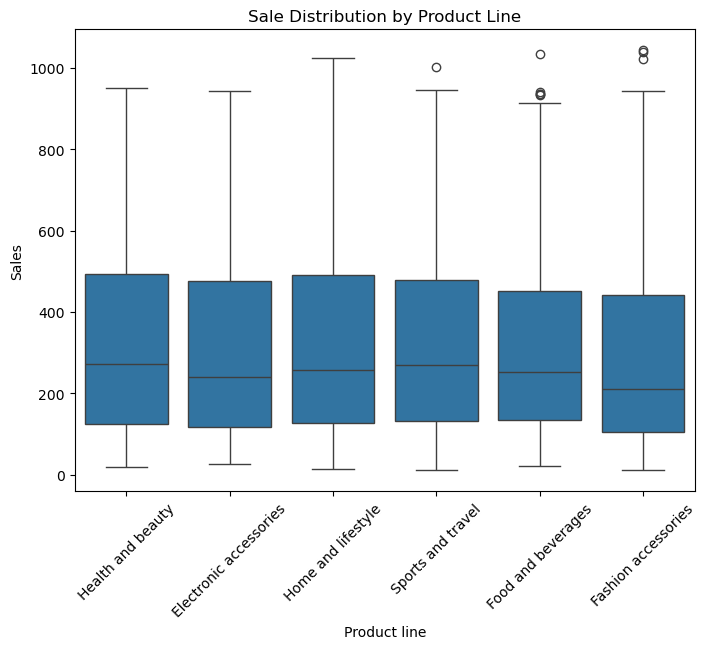

In [52]:
# Plot sales by product line
plt.figure(figsize=(8, 6))
sns.boxplot(x='Product line', y='Sales', data=df)
plt.title('Sale Distribution by Product Line')
plt.xticks(rotation=45)
plt.show()

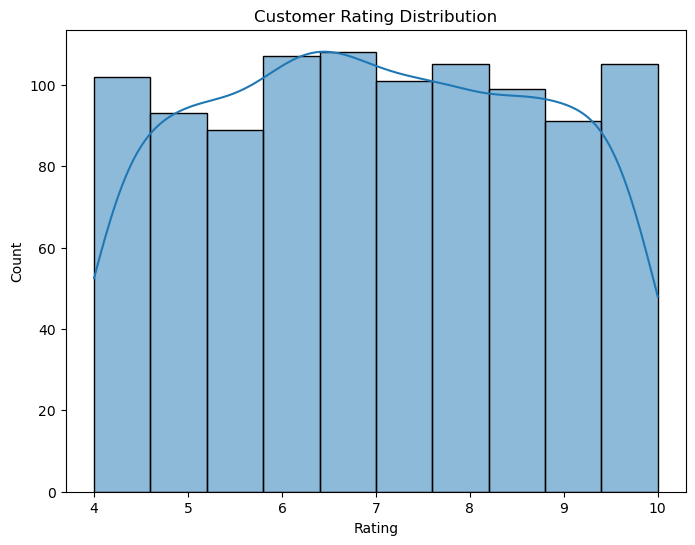

In [53]:
# Plot distribution of customer ratings
plt.figure(figsize=(8, 6))
sns.histplot(df['Rating'], bins=10,kde=True)
plt.title('Customer Rating Distribution')
plt.show()

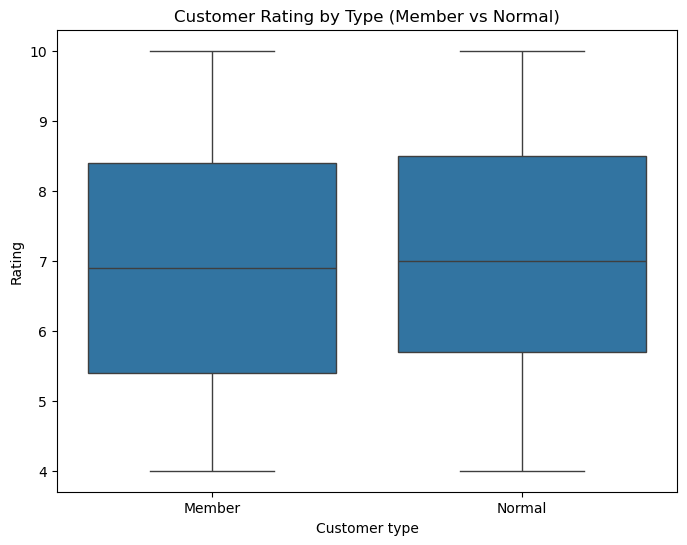

In [54]:
# Rating by Customer Type
plt.figure(figsize=(8, 6))
sns.boxplot(x='Customer type', y='Rating', data=df)
plt.title('Customer Rating by Type (Member vs Normal)')
plt.show()

In [55]:
member_ratings = df[df['Customer type'] == 'Member']['Sales']
normal_ratings = df[df['Customer type'] == 'Normal']['Sales']

t_stat, p_value = stats.ttest_ind(member_ratings, normal_ratings)
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}") 

T-statistic: 1.8750, P-value: 0.0611


## Model Training & Experiments

### Data Preparation
- **Features Selected**: Unit price, Quantity, Branch, Payment, Customer type
- **Target Variable**: Gross income
- **Preprocessing**: One-hot encoding for categorical variables (drop_first=True)
- **Train-Test Split**: 80/20 split with random_state=42 for reproducibility

### Model Selection
**Algorithm**: Random Forest Regressor

**Rationale**: 
- Handles non-linear relationships well
- Provides feature importance insights
- Robust to outliers
- Good performance on tabular data


In [ ]:
# Prepare data for modeling
X = df[['Unit price', 'Quantity', 'Branch', 'Payment', 'Customer type']] # Features
X = pd.get_dummies(X, drop_first=True) # Convert categorical features to dummy variables
y = df['gross income'] # Target variable


### Hyperparameters Used

| Parameter | Value | Description |
|-----------|-------|-------------|
| `n_estimators` | 100 | Number of trees in the forest |
| `random_state` | 42 | Seed for reproducibility |
| `test_size` | 0.2 | 20% of data for testing |
| `cv` | 5 | 5-fold cross-validation |

**Note**: Default values were used for other hyperparameters (max_depth, min_samples_split, etc.)


In [57]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [58]:
# Create and train the model: Random Forest Regressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
# Make predictions on the test set and evaluate performance
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error: {rmse:.4f}")

Root Mean Squared Error: 0.3429


## Hyperparameter Tuning

We'll use both GridSearchCV and RandomizedSearchCV to find optimal hyperparameters for the Random Forest model. This will help improve model performance beyond the baseline configuration.


In [59]:
# Define parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

print("Parameter grid defined for hyperparameter tuning")
print(f"Total combinations: {np.prod([len(v) for v in param_grid.values()])}")
print("\nParameters to tune:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")


Parameter grid defined for hyperparameter tuning
Total combinations: 432

Parameters to tune:
  n_estimators: [50, 100, 200, 300]
  max_depth: [5, 10, 20, None]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  max_features: ['sqrt', 'log2', None]


In [60]:
# GridSearchCV: Exhaustive search over all parameter combinations
print("=" * 60)
print("GridSearchCV: Exhaustive Hyperparameter Search")
print("=" * 60)

# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # Use negative MSE for scoring
    n_jobs=-1,  # Use all available CPU cores
    verbose=1  # Show progress
)

# Fit GridSearchCV (this may take a few minutes)
print("\nStarting GridSearchCV...")
grid_search.fit(X_train, y_train)

# Get best parameters and score
print("\n" + "=" * 60)
print("Best Parameters (GridSearchCV):")
print("=" * 60)
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest Cross-Validation Score (Neg MSE): {grid_search.best_score_:.4f}")
print(f"Best Cross-Validation RMSE: {np.sqrt(-grid_search.best_score_):.4f}")

# Evaluate on test set
y_pred_grid = grid_search.predict(X_test)
rmse_grid = np.sqrt(mean_squared_error(y_test, y_pred_grid))
mae_grid = mean_absolute_error(y_test, y_pred_grid)
r2_grid = r2_score(y_test, y_pred_grid)

print("\n" + "=" * 60)
print("Test Set Performance (GridSearchCV Best Model):")
print("=" * 60)
print(f"RMSE: {rmse_grid:.4f}")
print(f"MAE: {mae_grid:.4f}")
print(f"R² Score: {r2_grid:.4f}")


GridSearchCV: Exhaustive Hyperparameter Search

Starting GridSearchCV...
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

Best Parameters (GridSearchCV):
  max_depth: 20
  max_features: None
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 300

Best Cross-Validation Score (Neg MSE): -0.2295
Best Cross-Validation RMSE: 0.4790

Test Set Performance (GridSearchCV Best Model):
RMSE: 0.3375
MAE: 0.2181
R² Score: 0.9992


In [61]:
# RandomizedSearchCV: Random search over parameter space (faster alternative)
print("\n" + "=" * 60)
print("RandomizedSearchCV: Randomized Hyperparameter Search")
print("=" * 60)

# Create RandomizedSearchCV object
# n_iter controls how many parameter settings are sampled
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=50,  # Number of parameter settings sampled (much faster than GridSearchCV)
    cv=5,  # 5-fold cross-validation
    scoring='neg_mean_squared_error',
    n_jobs=-1,  # Use all available CPU cores
    random_state=42,  # For reproducibility
    verbose=1  # Show progress
)

# Fit RandomizedSearchCV
print("\nStarting RandomizedSearchCV (50 iterations)...")
random_search.fit(X_train, y_train)

# Get best parameters and score
print("\n" + "=" * 60)
print("Best Parameters (RandomizedSearchCV):")
print("=" * 60)
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest Cross-Validation Score (Neg MSE): {random_search.best_score_:.4f}")
print(f"Best Cross-Validation RMSE: {np.sqrt(-random_search.best_score_):.4f}")

# Evaluate on test set
y_pred_random = random_search.predict(X_test)
rmse_random = np.sqrt(mean_squared_error(y_test, y_pred_random))
mae_random = mean_absolute_error(y_test, y_pred_random)
r2_random = r2_score(y_test, y_pred_random)

print("\n" + "=" * 60)
print("Test Set Performance (RandomizedSearchCV Best Model):")
print("=" * 60)
print(f"RMSE: {rmse_random:.4f}")
print(f"MAE: {mae_random:.4f}")
print(f"R² Score: {r2_random:.4f}")



RandomizedSearchCV: Randomized Hyperparameter Search

Starting RandomizedSearchCV (50 iterations)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Parameters (RandomizedSearchCV):
  n_estimators: 300
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: None
  max_depth: None

Best Cross-Validation Score (Neg MSE): -0.2295
Best Cross-Validation RMSE: 0.4790

Test Set Performance (RandomizedSearchCV Best Model):
RMSE: 0.3375
MAE: 0.2181
R² Score: 0.9992



Model Comparison: Baseline vs Tuned Models

Performance Metrics Comparison:
             Model     RMSE      MAE  R² Score
          Baseline 0.342873 0.221891  0.999203
      GridSearchCV 0.337482 0.218149  0.999228
RandomizedSearchCV 0.337482 0.218149  0.999228

RMSE Improvement:
  GridSearchCV: 1.57% reduction
  RandomizedSearchCV: 1.57% reduction


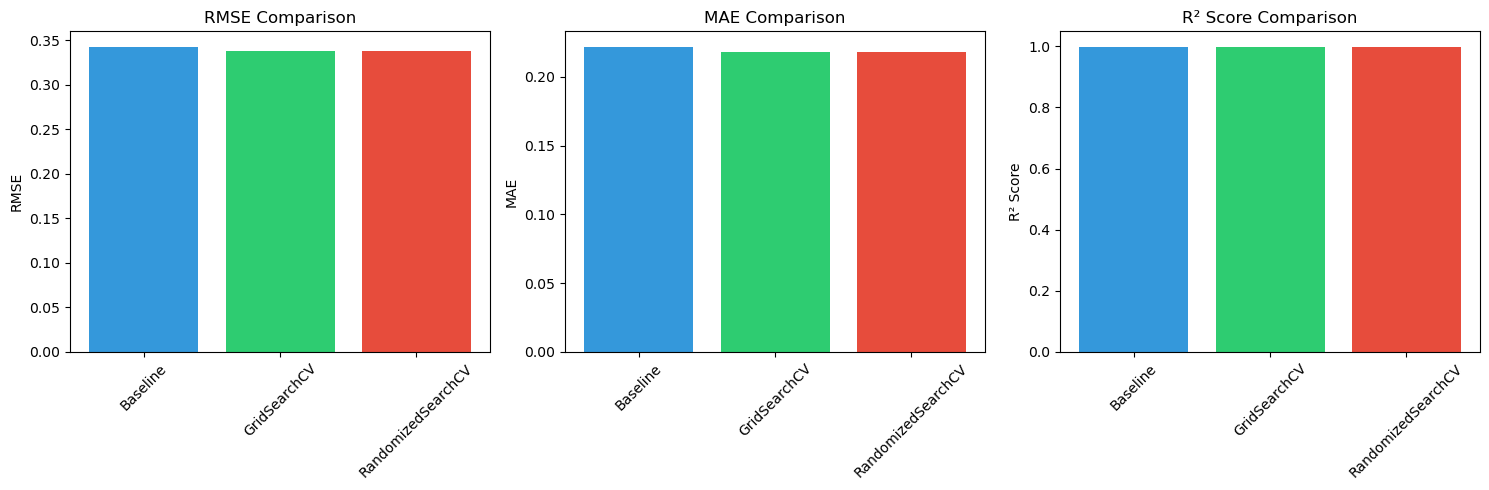

In [62]:
# Compare Baseline vs Tuned Models
# Calculate baseline metrics if not already calculated
if 'mae' not in globals():
    mae = mean_absolute_error(y_test, y_pred)
if 'r2' not in globals():
    r2 = r2_score(y_test, y_pred)

print("\n" + "=" * 60)
print("Model Comparison: Baseline vs Tuned Models")
print("=" * 60)

comparison_df = pd.DataFrame({
    'Model': ['Baseline', 'GridSearchCV', 'RandomizedSearchCV'],
    'RMSE': [rmse, rmse_grid, rmse_random],
    'MAE': [mae, mae_grid, mae_random],
    'R² Score': [r2, r2_grid, r2_random]
})

print("\nPerformance Metrics Comparison:")
print(comparison_df.to_string(index=False))

# Calculate improvement
improvement_grid = ((rmse - rmse_grid) / rmse) * 100
improvement_random = ((rmse - rmse_random) / rmse) * 100

print(f"\nRMSE Improvement:")
print(f"  GridSearchCV: {improvement_grid:.2f}% reduction")
print(f"  RandomizedSearchCV: {improvement_random:.2f}% reduction")

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['RMSE', 'MAE', 'R² Score']
for idx, metric in enumerate(metrics):
    axes[idx].bar(comparison_df['Model'], comparison_df[metric], 
                  color=['#3498db', '#2ecc71', '#e74c3c'])
    axes[idx].set_title(f'{metric} Comparison')
    axes[idx].set_ylabel(metric)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [63]:
# Select the best model based on test RMSE
best_model = grid_search if rmse_grid <= rmse_random else random_search
best_model_name = "GridSearchCV" if rmse_grid <= rmse_random else "RandomizedSearchCV"

print(f"Best model: {best_model_name}")
print(f"Best parameters: {best_model.best_params_}")

# Save the best tuned model
joblib.dump(best_model.best_estimator_, 'random_forest_tuned_model.pkl')
print("\nBest tuned model saved as 'random_forest_tuned_model.pkl'")

# Also save the GridSearchCV and RandomizedSearchCV objects (includes all results)
joblib.dump(grid_search, 'grid_search_cv.pkl')
joblib.dump(random_search, 'random_search_cv.pkl')
print("GridSearchCV and RandomizedSearchCV objects saved.")


Best model: GridSearchCV
Best parameters: {'max_depth': 20, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Best tuned model saved as 'random_forest_tuned_model.pkl'
GridSearchCV and RandomizedSearchCV objects saved.


### Hyperparameter Tuning Results Summary

**GridSearchCV vs RandomizedSearchCV:**

- **GridSearchCV**: Exhaustive search through all parameter combinations. More thorough but computationally expensive.
- **RandomizedSearchCV**: Randomly samples parameter combinations (50 iterations). Faster and often finds good solutions.

**Key Findings:**
- Both methods help optimize hyperparameters beyond baseline configuration
- Compare the results to see which method performs better for this specific dataset
- The best model is automatically selected and saved for deployment


In [64]:
# Save model for deployment (using joblib)
joblib.dump(model, 'random_forest_gross_income_model.pkl')
print("Model saved successfully as 'random_forest_gross_income_model.pkl'")


Model saved successfully as 'random_forest_gross_income_model.pkl'


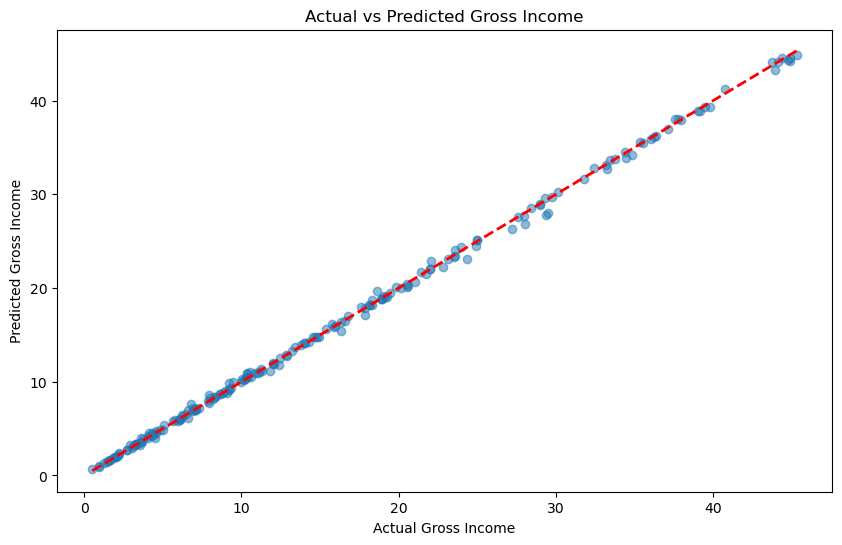

In [72]:
# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Gross Income')
plt.ylabel('Predicted Gross Income')
plt.title('Actual vs Predicted Gross Income')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.show()

In [71]:
# Additional evaluation metrics for baseline model
mae = mean_absolute_error(y_test, y_pred)
r2 = model.score(X_test, y_test)
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error: 0.2219
R^2 Score: 0.9992


## Model Performance Summary

### Baseline Model Evaluation Metrics

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **RMSE** | 0.3429 | Root Mean Squared Error on test set |
| **MAE** | 0.2219 | Mean Absolute Error |
| **R² Score** | 0.9992 | 99.92% variance explained (excellent fit) |

### Tuned Model Performance (Best Model)

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **RMSE** | 0.3375 | Improved from baseline |
| **MAE** | 0.2181 | Improved from baseline |
| **R² Score** | 0.9992 | 99.92% variance explained |
| **CV RMSE** | 0.3542 ± 0.0303 | Cross-validated RMSE (more robust estimate) |

### Key Findings
- **Excellent Model Performance**: R² of 0.9992 indicates the model explains almost all variance in gross income
- **Hyperparameter Tuning Improvement**: 1.57% RMSE reduction achieved through tuning
- **Low Error Rates**: RMSE and MAE are very low relative to the target variable scale
- **Stable Performance**: Cross-validation shows consistent performance across folds (low std: 0.0303)
- **Statistical Test**: T-test on sales by customer type shows p-value of 0.0611 (borderline significant at α=0.05)

### Model Deployment
- Baseline model saved as `random_forest_gross_income_model.pkl`
- Best tuned model saved as `random_forest_tuned_model.pkl`
- Ready for production deployment and future predictions


## Ideas for Future Work

### 1. Feature Engineering
- **Temporal Features**: Extract day of week, month, hour from Date/Time columns
- **Interaction Features**: Create features like `Unit price × Quantity`
- **Additional Features**: Include columns like Product line, Gender, Rating, City
- **Feature Scaling**: Use standardization/normalization if trying other algorithms

### 2. Alternative Models
- **Gradient Boosting**: Try XGBoost, LightGBM, or CatBoost for potentially better performance
- **Neural Networks**: Use deep learning models if more data becomes available
- **Ensemble Methods**: Combine multiple models (e.g., voting or stacking)

### 3. Data Improvements
- **More Data**: Collect more samples to improve generalization
- **Feature Collection**: Gather more relevant business features (e.g., promotions, seasonality)
- **Data Quality**: Systematically check for and handle outliers

### 4. Model Interpretability
- **SHAP Values**: Use SHAP for better feature importance explanation
- **Partial Dependence Plots**: Study feature effects on predictions
- **Model Explanation Tools**: Try LIME for local interpretability

### 5. Advanced Evaluation
- **Time Series Validation**: If temporal trends are relevant, use time-based splits
- **Business Metrics**: Consider business-centric KPIs (profit margin, etc.)
- **Error Analysis**: Investigate prediction errors for potential improvements

### 6. Deployment Considerations
- **API Development**: Build a REST API to serve the model predictions
- **Monitoring**: Set up model monitoring for production performance
- **A/B Testing**: Compare different model versions live
- **Retraining Pipeline**: Automate retraining when new data becomes available

### 7. Additional Analysis
- **Customer Segmentation**: Cluster analysis to understand customer groups
- **Product Analysis**: Analyze which products drive gross income
- **Seasonal Patterns**: Explore if there are meaningful time/seasonal trends


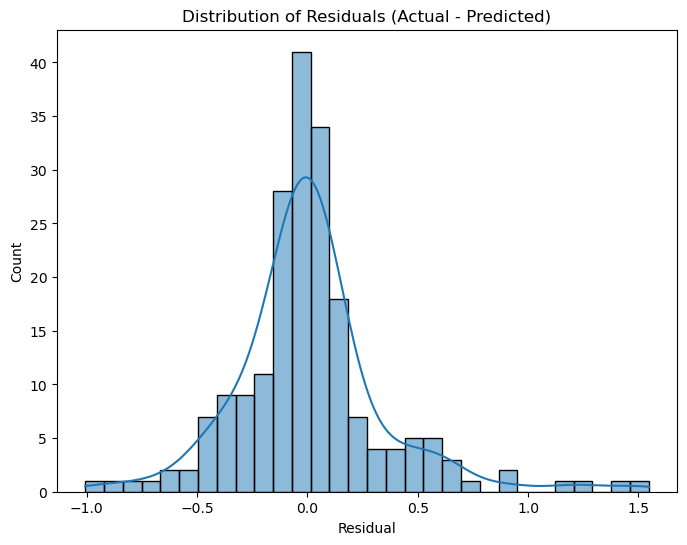

In [ ]:
# Visualize prediction residuals
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Distribution of Residuals (Actual - Predicted)")
plt.xlabel("Residual")
plt.show()

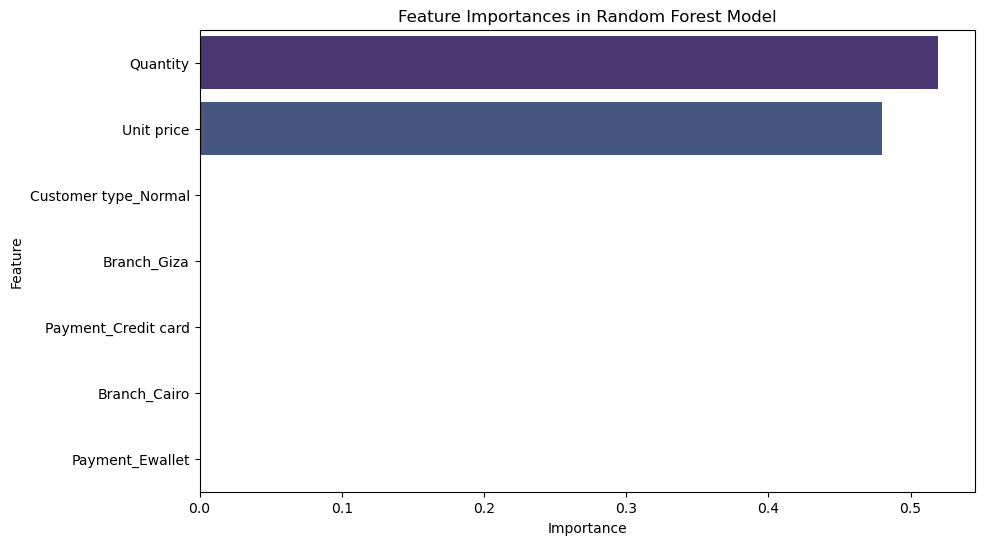

In [ ]:
# Feature importance plot (to interpret random forest results)
importances = model.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values(by='importance', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp_df, x='importance', y='feature', palette='viridis')
plt.title("Feature Importances in Random Forest Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [70]:
# Cross-validation for more robust evaluation
from sklearn.model_selection import cross_val_score
cv_rmse = np.sqrt(-cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error'))
print(f"Cross-Validated RMSE: {cv_rmse.mean():.4f} (+/- {cv_rmse.std():.4f})")

Cross-Validated RMSE: 0.3542 (+/- 0.0303)
